### EMPLOYEE AND WORKER DATA ANALYSIS

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
df = pd.read_excel("Book1.xlsx")

df.head()
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 8 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype 
---  ------                                                                                                                              --------------  ----- 
 0   Unnamed: 0                                                                                                                          127 non-null    object
 1   Unnamed: 1                                                                                                                          132 non-null    object
 2                                                                                             BHARDESWAR  TEA  PLANTATION  CO. (P) LTD  132 non-null    object
 3   Unnamed: 3                                                                                 

In [ ]:

df = df.iloc[3:].reset_index(drop=True)


df.columns = [
    "SL_NO",
    "EMPLOYEE_NAME",
    "WORKING_DAYS",
    "RATE",
    "AMOUNT",
    "PF_DEDUCTION",
    "PAYABLE_AMOUNT",
    "SIGNATURE"
]

df.head(10)


,SL_NO,EMPLOYEE_NAME,WORKING_DAYS,RATE,AMOUNT,PF_DEDUCTION,PAYABLE_AMOUNT,SIGNATURE
0,4,ATUL SEN,4,220,880,105.6,774.4,NaN
1,5,SUBASH ROY,4,220,880,105.6,774.4,NaN
2,6,BHUPEN ROY,4,220,880,105.6,774.4,NaN
3,7,SUNIL ROY (1),4,220,880,105.6,774.4,NaN
4,8,ANIL ROY (2),4,220,880,105.6,774.4,NaN
5,9,DHANESH CH. ROY,4,220,880,105.6,774.4,NaN
6,10,PROFULLYA ROY,4,220,880,105.6,774.4,NaN
7,11,AMULLYA ROY,4,220,880,105.6,774.4,NaN
8,12,BIDHAN CH. ROY,4,220,880,105.6,774.4,NaN
9,13,SABUL MD,4,220,880,105.6,774.4,NaN


In [ ]:

numeric_cols = ["WORKING_DAYS", "RATE", "AMOUNT", "PF_DEDUCTION", "PAYABLE_AMOUNT"]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SL_NO           123 non-null    object 
 1   EMPLOYEE_NAME   128 non-null    object 
 2   WORKING_DAYS    127 non-null    float64
 3   RATE            122 non-null    float64
 4   AMOUNT          123 non-null    float64
 5   PF_DEDUCTION    111 non-null    float64
 6   PAYABLE_AMOUNT  111 non-null    float64
 7   SIGNATURE       0 non-null      object 
dtypes: float64(5), object(3)
memory usage: 9.8+ KB


In [ ]:

df = df.dropna(subset=["PAYABLE_AMOUNT"])


df = df[df["PAYABLE_AMOUNT"] > 0]

df.shape


(107, 8)

In [ ]:
# Check missing values column-wise
df.isnull().sum()


,0
SL_NO,0
EMPLOYEE_NAME,0
WORKING_DAYS,0
RATE,0
AMOUNT,0
PF_DEDUCTION,0
PAYABLE_AMOUNT,0
SIGNATURE,107


In [ ]:

df["PF_DEDUCTION"] = df["PF_DEDUCTION"].fillna(0)


In [ ]:
total_payable = df["PAYABLE_AMOUNT"].sum()
avg_payable = df["PAYABLE_AMOUNT"].mean()
max_payable = df["PAYABLE_AMOUNT"].max()
min_payable = df["PAYABLE_AMOUNT"].min()

total_payable, avg_payable, max_payable, min_payable


(np.float64(60209.6), np.float64(562.7065420560748), 774.4, 193.6)

In [ ]:
df.sort_values("PAYABLE_AMOUNT", ascending=False).head(5)


,SL_NO,EMPLOYEE_NAME,WORKING_DAYS,RATE,AMOUNT,PF_DEDUCTION,PAYABLE_AMOUNT,SIGNATURE
0,4,ATUL SEN,4.0,220.0,880.0,105.6,774.4,NaN
1,5,SUBASH ROY,4.0,220.0,880.0,105.6,774.4,NaN
2,6,BHUPEN ROY,4.0,220.0,880.0,105.6,774.4,NaN
3,7,SUNIL ROY (1),4.0,220.0,880.0,105.6,774.4,NaN
4,8,ANIL ROY (2),4.0,220.0,880.0,105.6,774.4,NaN


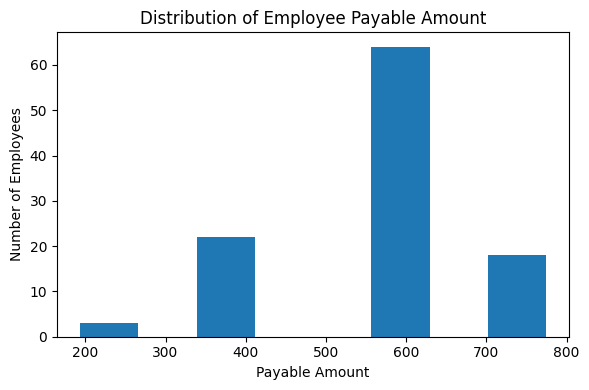

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["PAYABLE_AMOUNT"], bins=8)
plt.title("Distribution of Employee Payable Amount")
plt.xlabel("Payable Amount")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()


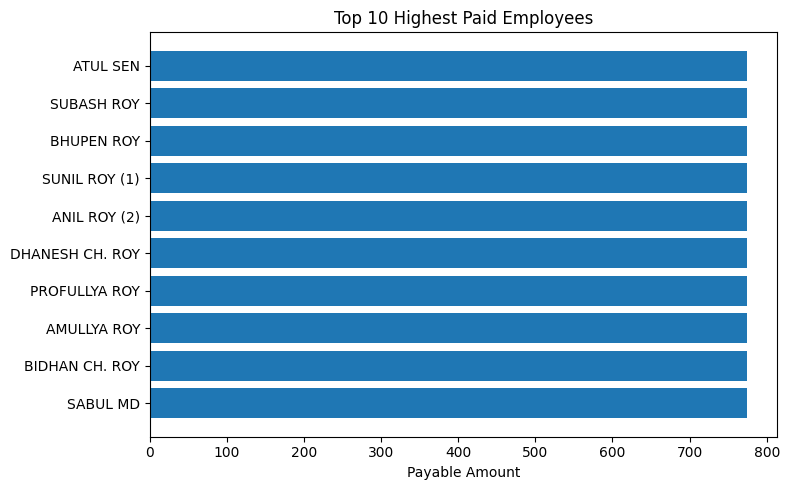

In [ ]:
top10 = df.sort_values("PAYABLE_AMOUNT", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["EMPLOYEE_NAME"], top10["PAYABLE_AMOUNT"])
plt.gca().invert_yaxis()
plt.xlabel("Payable Amount")
plt.title("Top 10 Highest Paid Employees")
plt.tight_layout()
plt.show()


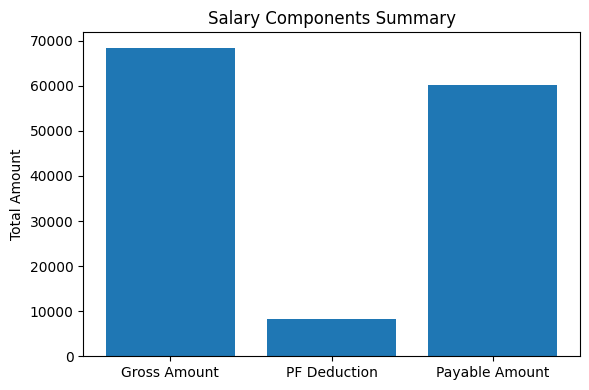

In [ ]:
components = {
    "Gross Amount": df["AMOUNT"].sum(),
    "PF Deduction": df["PF_DEDUCTION"].sum(),
    "Payable Amount": df["PAYABLE_AMOUNT"].sum()
}

plt.figure(figsize=(6,4))
plt.bar(components.keys(), components.values())
plt.title("Salary Components Summary")
plt.ylabel("Total Amount")
plt.tight_layout()
plt.show()


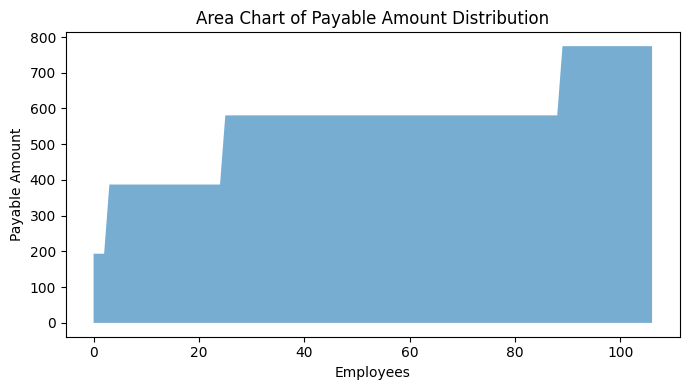

In [ ]:
salary_dist = df["PAYABLE_AMOUNT"].sort_values().reset_index(drop=True)

plt.figure(figsize=(7,4))
plt.fill_between(range(len(salary_dist)), salary_dist, alpha=0.6)
plt.title("Area Chart of Payable Amount Distribution")
plt.xlabel("Employees")
plt.ylabel("Payable Amount")
plt.tight_layout()
plt.show()


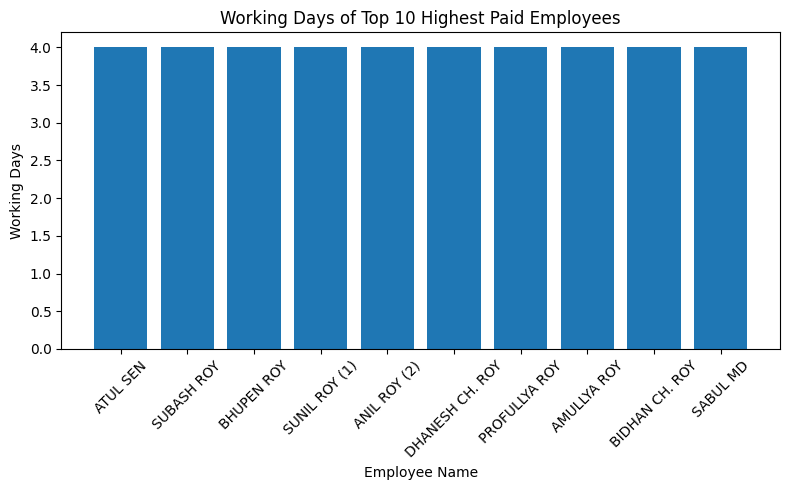

In [ ]:
top10_days = df.sort_values("PAYABLE_AMOUNT", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.bar(top10_days["EMPLOYEE_NAME"], top10_days["WORKING_DAYS"])
plt.xticks(rotation=45)
plt.title("Working Days of Top 10 Highest Paid Employees")
plt.xlabel("Employee Name")
plt.ylabel("Working Days")
plt.tight_layout()
plt.show()


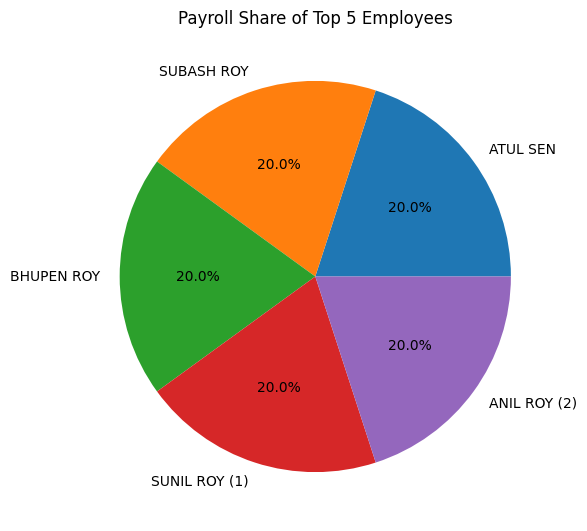

In [ ]:
top5 = df.sort_values("PAYABLE_AMOUNT", ascending=False).head(5)

plt.figure(figsize=(6,6))
plt.pie(top5["PAYABLE_AMOUNT"], labels=top5["EMPLOYEE_NAME"], autopct='%1.1f%%')
plt.title("Payroll Share of Top 5 Employees")
plt.tight_layout()
plt.show()


In [ ]:
df.to_excel("Cleaned_Employee_Salary_Data.xlsx", index=False)


**EMPLOYEE POLICY DATA ANALYSIS  Policy No : 405001426**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("Employes Policy No405001426.xlsx")
df.head()


,Policy No,405001426,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,SL NO.,LIC ID,Category,DOB,DOA,Gender,Name,LCP
1,1,115,1,1987-05-20 00:00:00,2017-05-02 00:00:00,M,AMIT KUMAR DAS,8000
2,2,116,1,1987-03-15 00:00:00,2019-03-02 00:00:00,M,KRISHNA SHING,5720
3,4,117,1,1978-10-10 00:00:00,2015-06-01 00:00:00,F,SANIKA ROY,5720
4,5,118,1,1982-01-01 00:00:00,2013-07-02 00:00:00,M,GOURANGA ROY,5720


In [ ]:

df.columns = df.iloc[0]
df = df[1:].reset_index(drop=True)


df.columns = df.columns.str.strip()

df.head()


,SL NO.,LIC ID,Category,DOB,DOA,Gender,Name,LCP
0,1,115,1,1987-05-20 00:00:00,2017-05-02 00:00:00,M,AMIT KUMAR DAS,8000
1,2,116,1,1987-03-15 00:00:00,2019-03-02 00:00:00,M,KRISHNA SHING,5720
2,4,117,1,1978-10-10 00:00:00,2015-06-01 00:00:00,F,SANIKA ROY,5720
3,5,118,1,1982-01-01 00:00:00,2013-07-02 00:00:00,M,GOURANGA ROY,5720
4,6,119,1,1985-01-01 00:00:00,2013-08-05 00:00:00,M,GOUTAM ROY,5720


In [ ]:
df.info()
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   SL NO.    74 non-null     object
 1   LIC ID    74 non-null     object
 2   Category  74 non-null     object
 3   DOB       74 non-null     object
 4   DOA       74 non-null     object
 5   Gender    74 non-null     object
 6   Name      74 non-null     object
 7   LCP       74 non-null     object
dtypes: object(8)
memory usage: 4.8+ KB


Index(['SL NO.', 'LIC ID', 'Category', 'DOB', 'DOA', 'Gender', 'Name', 'LCP'], dtype='object', name=0)

In [ ]:
df["DOB"] = pd.to_datetime(df["DOB"], errors="coerce")
df["DOA"] = pd.to_datetime(df["DOA"], errors="coerce")
df["LCP"] = pd.to_numeric(df["LCP"], errors="coerce")


In [ ]:

df = df.dropna(subset=["Name", "LCP"])


df = df[df["LCP"] > 0]

df.shape


(74, 8)

In [ ]:
df.isnull().sum()


,0
0,
SL NO.,0
LIC ID,0
Category,0
DOB,1
DOA,0
Gender,0
Name,0
LCP,0


In [ ]:
df["AGE"] = (pd.Timestamp.today() - df["DOB"]).dt.days // 365


In [ ]:
df["EXPERIENCE_YEARS"] = (pd.Timestamp.today() - df["DOA"]).dt.days // 365


In [ ]:
df["LCP"].describe()


,LCP
count,74.000000
mean,5846.216216
std,631.006378
min,5720.000000
25%,5720.000000
50%,5720.000000
75%,5720.000000
max,9500.000000


In [ ]:
df.sort_values("LCP", ascending=False).head(5)


,SL NO.,LIC ID,Category,DOB,DOA,Gender,Name,LCP,AGE,EXPERIENCE_YEARS
15,19,132,1,1979-02-04,2021-04-01,M,JAYANTA JHA,9500,47.0,4
14,18,131,1,1977-12-30,2021-01-01,M,JOYASHIS DEY,9000,48.0,5
0,1,115,1,1987-05-20,2017-05-02,M,AMIT KUMAR DAS,8000,38.0,8
3,5,118,1,1982-01-01,2013-07-02,M,GOURANGA ROY,5720,44.0,12
2,4,117,1,1978-10-10,2015-06-01,F,SANIKA ROY,5720,47.0,10


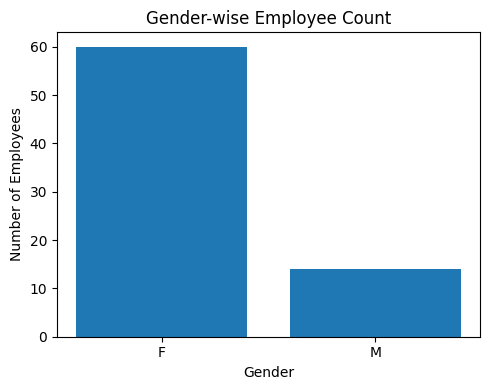

In [ ]:
gender_count = df["Gender"].value_counts()

plt.figure(figsize=(5,4))
plt.bar(gender_count.index, gender_count.values)
plt.title("Gender-wise Employee Count")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()


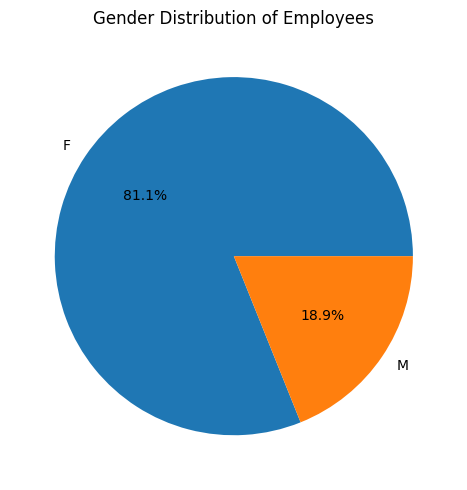

In [ ]:
plt.figure(figsize=(5,5))
plt.pie(gender_count.values, labels=gender_count.index, autopct='%1.1f%%')
plt.title("Gender Distribution of Employees")
plt.tight_layout()
plt.show()


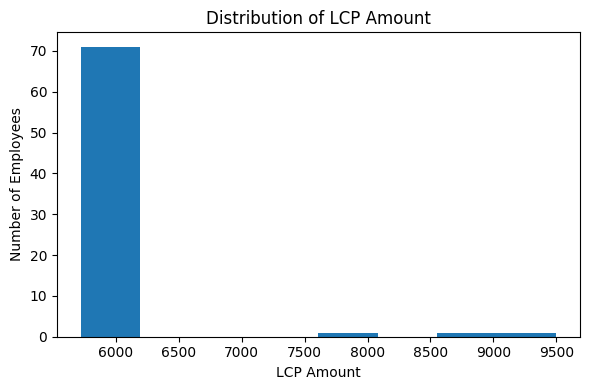

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["LCP"], bins=8)
plt.title("Distribution of LCP Amount")
plt.xlabel("LCP Amount")
plt.ylabel("Number of Employees")
plt.tight_layout()
plt.show()


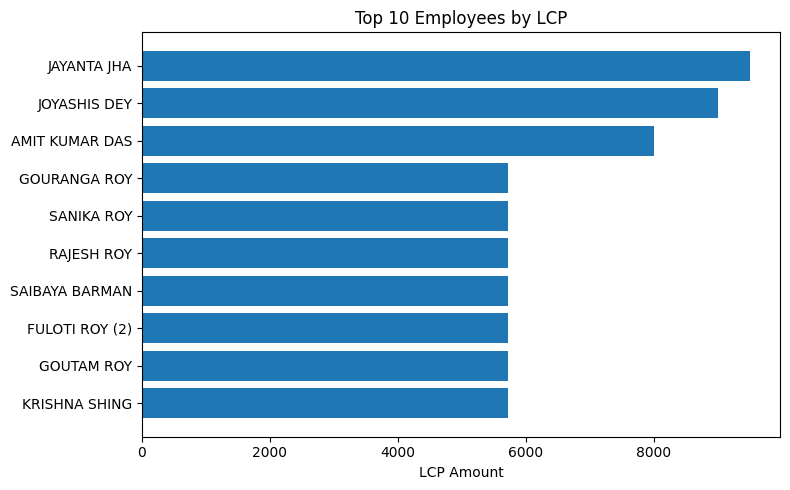

In [ ]:
top10 = df.sort_values("LCP", ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Name"], top10["LCP"])
plt.gca().invert_yaxis()
plt.title("Top 10 Employees by LCP")
plt.xlabel("LCP Amount")
plt.tight_layout()
plt.show()


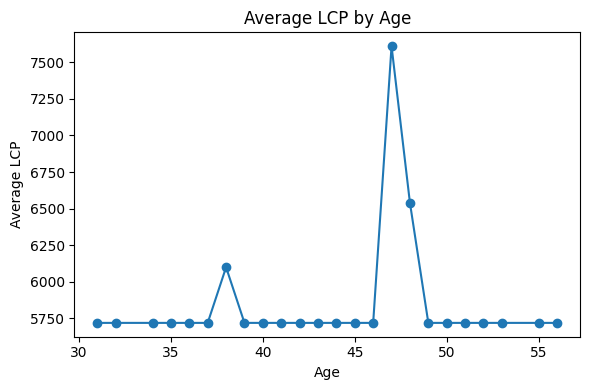

In [ ]:
age_group = df.groupby("AGE")["LCP"].mean()

plt.figure(figsize=(6,4))
plt.plot(age_group.index, age_group.values, marker='o')
plt.title("Average LCP by Age")
plt.xlabel("Age")
plt.ylabel("Average LCP")
plt.tight_layout()
plt.show()


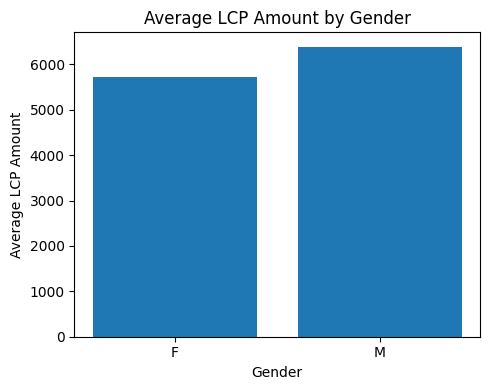

In [ ]:
gender_lcp_avg = df.groupby("Gender")["LCP"].mean()

plt.figure(figsize=(5,4))
plt.bar(gender_lcp_avg.index, gender_lcp_avg.values)
plt.title("Average LCP Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Average LCP Amount")
plt.tight_layout()
plt.show()


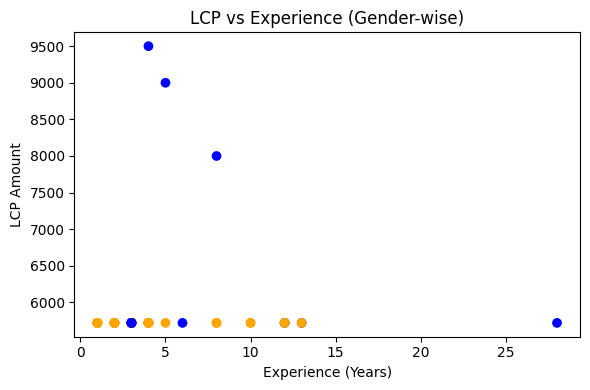

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df["EXPERIENCE_YEARS"], df["LCP"], c=df["Gender"].map({'M':'blue','F':'orange'}))
plt.title("LCP vs Experience (Gender-wise)")
plt.xlabel("Experience (Years)")
plt.ylabel("LCP Amount")
plt.tight_layout()
plt.show()


In [ ]:
df.to_excel("Cleaned_Employee_Policy_Data.xlsx", index=False)


BALANCE SHEET ANALYSIS
PROFIT & LOSS EXPENSE ANALYSIS
DEPRECIATION ASSET LONG-TERM ANALYSIS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = "Copy of Bhardeswar T.P.C.P.Ltd. - 2022-23.xlsx"

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "Copy of Bhardeswar T.P.C.P.Ltd. - 2022-23.xlsx"

xls = pd.ExcelFile(file_path)
xls.sheet_names


['Balance Sheet & Profit and Loss',
 'Notes for Balance Sheet',
 'Notes for P & L',
 'Depreciation',
 'Sheet1',
 'Sheet2']

In [ ]:
bs_pl = pd.read_excel(file_path, sheet_name="Balance Sheet & Profit and Loss", header=5)
bs_pl = bs_pl.dropna(how="all")


bs_pl.columns = [
    "Particulars",
    "Note_No",
    "2025_Amount",
    "2024_Amount",
]


bs_pl["2025_Amount"] = pd.to_numeric(bs_pl["2025_Amount"], errors="coerce")
bs_pl["2024_Amount"] = pd.to_numeric(bs_pl["2024_Amount"], errors="coerce")

bs_pl.head()

,Particulars,Note_No,2025_Amount,2024_Amount
0,Particulars,Note No.,NaN,NaN
1,NaN,NaN,NaN,NaN
2,I. Revenue from operations,20,27387814.00,23037561.00
3,II. Other Income,21,368702.12,408560.76
4,III. Total Revenue (I+II),NaN,27756516.12,23446121.76


In [ ]:
numeric_cols = bs_pl.select_dtypes(include="number").columns
numeric_cols

Index(['2025_Amount', '2024_Amount'], dtype='object')

In [ ]:
print(f"Total Assets: {total_assets:,.2f}")
print(f"Total Liabilities: {total_liabilities:,.2f}")

Total Assets: 7,247,111.90
Total Liabilities: 166,776.00


In [ ]:
print(f"Revenue from Operations: {revenue_operations:,.2f}")
print(f"Other Income: {other_income:,.2f}")
print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Expenses: {total_expenses:,.2f}")
print(f"Profit Before Tax: {profit_before_tax:,.2f}")

Revenue from Operations: 27,387,814.00
Other Income: 368,702.12
Total Revenue: 27,756,516.12
Total Expenses: 23,527,909.37
Profit Before Tax: 4,228,606.75


In [ ]:
value_col = numeric_cols[0]

In [ ]:
assets = bs_pl[bs_pl.iloc[:,0].str.contains("ASSET", case=False, na=False)]
liabilities = bs_pl[bs_pl.iloc[:,0].str.contains("LIABILIT", case=False, na=False)]

total_assets = assets[value_col].sum()
total_liabilities = liabilities[value_col].sum()


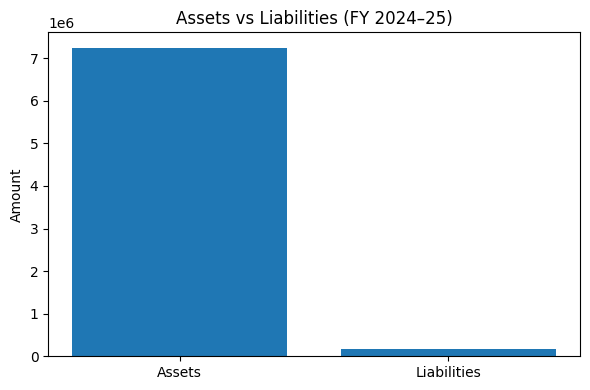

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(["Assets", "Liabilities"], [total_assets, total_liabilities])
plt.title("Assets vs Liabilities (FY 2024–25)")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()


In [ ]:
notes_bs = pd.read_excel(file_path, sheet_name="Notes for Balance Sheet")
notes_bs = notes_bs.dropna(how="all")
notes_bs.head()


,BHARDESWAR TEA PLANTATION COMPANY PRIVATE LIMITED,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,"REGISTERED OFFICE: BELAKOBA, P.O. - PRASANNANA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Notes forming part of the Balance Sheet as at ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,As at 31.03.2025,As at 31.03.2024,NaN,NaN,NaN
4,NaN,NaN,NaN,Rs. P.,Rs. P.,NaN,NaN,NaN
5,Note No.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
notes_bs = pd.read_excel(file_path, sheet_name="Notes for Balance Sheet")
notes_bs = notes_bs.dropna(how="all")
notes_bs.head()


,BHARDESWAR TEA PLANTATION COMPANY PRIVATE LIMITED,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,"REGISTERED OFFICE: BELAKOBA, P.O. - PRASANNANA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Notes forming part of the Balance Sheet as at ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,As at 31.03.2025,As at 31.03.2024,NaN,NaN,NaN
4,NaN,NaN,NaN,Rs. P.,Rs. P.,NaN,NaN,NaN
5,Note No.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN


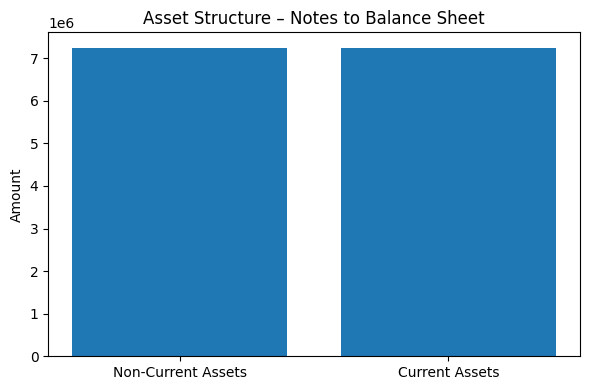

In [ ]:
# Non-Current Assets
non_current_assets_components = [
    'Tangible assets',
    'Intangible assets',
    'Deferred tax assets',
    'Long-term loans and advances'
]
non_current_assets_total = assets[assets['Particulars'].str.contains('|'.join(non_current_assets_components), case=False, na=False)][value_col].sum()

#  Current Assets
current_assets_header_idx = assets[assets['Particulars'].str.contains('Current assets:', case=False, na=False)].index[0]
current_assets_df = assets.loc[current_assets_header_idx:].copy()

current_assets_total = current_assets_df[value_col].sum()

plt.figure(figsize=(6,4))
plt.bar(["Non-Current Assets", "Current Assets"], [non_current_assets_total, current_assets_total])
plt.title("Asset Structure – Notes to Balance Sheet")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

In [ ]:
income = bs_pl[bs_pl.iloc[:,0].str.contains("INCOME|REVENUE|SALES", case=False, na=False)]
expenses = bs_pl[bs_pl.iloc[:,0].str.contains("EXPENSE|COST", case=False, na=False)]

total_income = income[value_col].sum()
total_expenses = expenses[value_col].sum()

net_profit = total_income - total_expenses

print(f"Total Income: {total_income:,.2f}")
print(f"Total Expenses: {total_expenses:,.2f}")

Total Income: 55,513,032.24
Total Expenses: 46,710,342.74


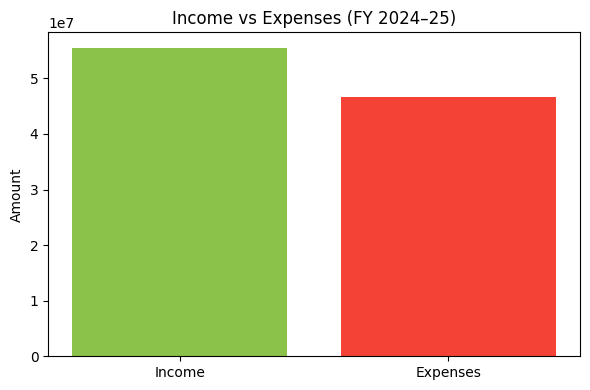

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(["Income", "Expenses"], [total_income, total_expenses], color=['#8BC34A', '#F44336'])
plt.title("Income vs Expenses (FY 2024–25)")
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

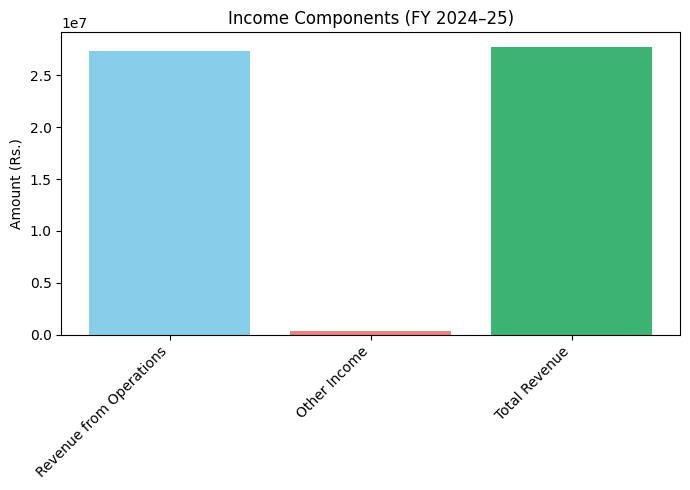

In [ ]:
labels = ['Revenue from Operations', 'Other Income', 'Total Revenue']
values = [revenue_operations, other_income, total_revenue]

plt.figure(figsize=(7,5))
plt.bar(labels, values, color=['skyblue', 'lightcoral', 'mediumseagreen'])
plt.title('Income Components (FY 2024–25)')
plt.ylabel('Amount (Rs.)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

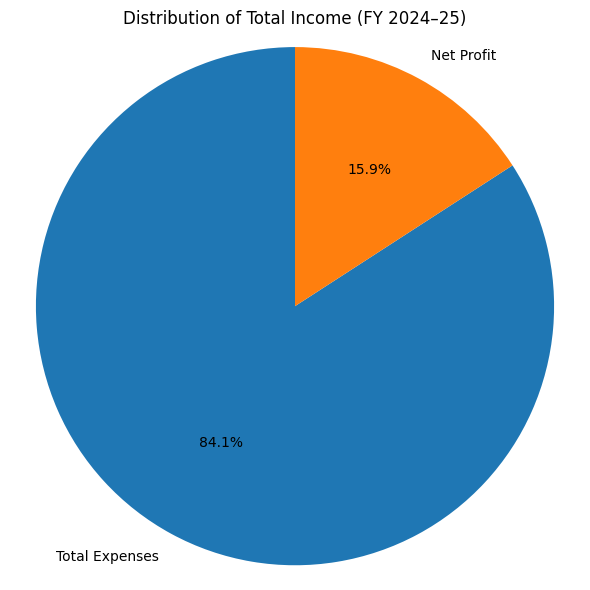

In [ ]:
plt.figure(figsize=(4,4))
plt.bar(["Net Result"], [net_profit])
plt.title("Net Profit / Loss (FY 2024–25)")
plt.tight_layout()
plt.show()


In [ ]:
notes_pl = pd.read_excel(file_path, sheet_name="Notes for P & L", header=3)
notes_pl = notes_pl.dropna(how="all")


notes_pl.rename(columns={
    notes_pl.columns[0]: "Particulars",
    notes_pl.columns[7]: "2025_Amount",
    notes_pl.columns[8]: "2024_Amount"
}, inplace=True)

notes_pl["2025_Amount"] = pd.to_numeric(notes_pl["2025_Amount"], errors="coerce")
notes_pl["2024_Amount"] = pd.to_numeric(notes_pl["2024_Amount"], errors="coerce")

notes_pl.head()

,Particulars,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,2025_Amount,2024_Amount
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Note No.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Revenue from Operation(Gross):,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Sale of Green tea leaf,NaN,NaN,NaN,NaN,NaN,NaN,27387814.0,23037561.0
4,Current year 978041 Kgs.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:

expenses_from_notes = notes_pl[notes_pl['Particulars'].str.contains('Cost of materials|Employee benefit|Finance Cost|Depreciation|Other expenses', case=False, na=False)]

print(f"--- Detailed Expenses (Year {value_col.split('_')[0]}) ---")
for index, row in expenses_from_notes.iterrows():
    if pd.notna(row['Particulars']) and pd.notna(row[value_col]):
        print(f"{row['Particulars']}: {row[value_col]:,.2f}")

#  total expenses
total_detailed_expenses = expenses_from_notes[value_col].sum()
print(f"Total Detailed Expenses: {total_detailed_expenses:,.2f}")

--- Detailed Expenses (Year 2025) ---
Total Detailed Expenses: 0.00


In [ ]:
depreciation_df = pd.read_excel(file_path, sheet_name="Depreciation", header=5)
depreciation_df = depreciation_df.dropna(how="all")


depreciation_df.columns = [
    "Asset_Name",
    "Rate_of_Depreciation",
    "Gross_Block_as_on_01_04_2024",
    "Additions_During_the_Year",
    "Deductions_During_the_Year",
    "Gross_Block_as_on_31_03_2025",
    "Depreciation_as_on_01_04_2024",
    "Depreciation_for_the_Year",
    "Adjustments_on_Account_of_Revaluation",
    "Depreciation_as_on_31_03_2025",
    "Net_Block_as_on_31_03_2025",
    "Net_Block_as_on_31_03_2024"
]


numeric_dep_cols = [
    "Gross_Block_as_on_01_04_2024",
    "Additions_During_the_Year",
    "Deductions_During_the_Year",
    "Gross_Block_as_on_31_03_2025",
    "Depreciation_as_on_01_04_2024",
    "Depreciation_for_the_Year",
    "Adjustments_on_Account_of_Revaluation",
    "Depreciation_as_on_31_03_2025",
    "Net_Block_as_on_31_03_2025",
    "Net_Block_as_on_31_03_2024"
]
depreciation_df[numeric_dep_cols] = depreciation_df[numeric_dep_cols].apply(pd.to_numeric, errors='coerce')


depreciation_df = depreciation_df[depreciation_df['Asset_Name'].notna() &
                                  ~depreciation_df['Asset_Name'].str.contains('Total|Name of Assets', case=False, na=False)]

depreciation_df.head()

,BHARDESWAR TEA PLANTATION COMPANY PRIVATE LIMITED,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,"REGISTERED OFFICE: BELAKOBA, P.O. - PRASANNANA...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Note No. -10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Notes forming part of the Balance Sheet as at ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"STATEMENT OF FIXED ASSETS AS AT 31st MARCH, 2025",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,(Tangible Assets),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
asset_names = depreciation_df.iloc[:, 0]
dep_values = depreciation_df.iloc[:, 7]

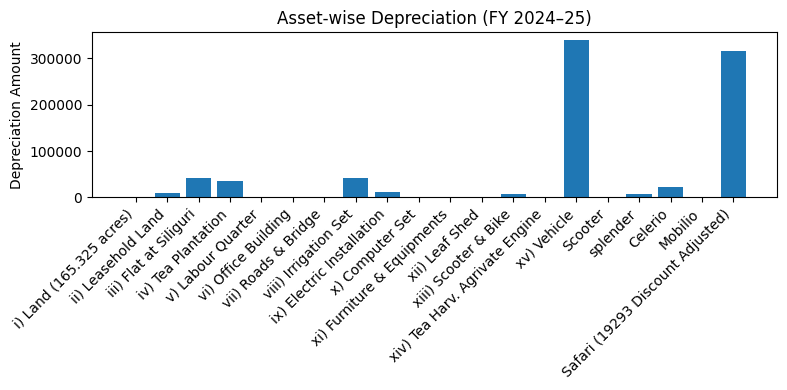

In [ ]:
plot_data = pd.DataFrame({'Asset': asset_names, 'Depreciation': dep_values})

plot_data['Depreciation'] = pd.to_numeric(plot_data['Depreciation'], errors='coerce')
plot_data = plot_data.dropna(subset=['Asset', 'Depreciation'])
plot_data['Asset'] = plot_data['Asset'].astype(str)

plt.figure(figsize=(8,4))
plt.bar(plot_data['Asset'], plot_data['Depreciation'])
plt.xticks(rotation=45, ha="right")
plt.title("Asset-wise Depreciation (FY 2024–25)")
plt.ylabel("Depreciation Amount")
plt.tight_layout()
plt.show()

In [ ]:
display(profit_loss_section.head())

,Particulars,Note_No,2025_Amount,2024_Amount
2,I. Revenue from operations,20,27387814.00,23037561.00
3,II. Other Income,21,368702.12,408560.76
4,III. Total Revenue (I+II),NaN,27756516.12,23446121.76
6,IV. Expenses:,NaN,NaN,NaN
8,Employee benefit expenses,23,10925626.20,10231739.03


In [ ]:
print("--- Profit & Loss Comparison (2025 vs 2024) ---")
for index, row in profit_loss_section.iterrows():
    particulars = row['Particulars']
    amount_2025 = row['2025_Amount']
    amount_2024 = row['2024_Amount']
    print(f"{particulars:<40} 2025: {amount_2025:,.2f}    2024: {amount_2024:,.2f}")

--- Profit & Loss Comparison (2025 vs 2024) ---
I. Revenue from operations               2025: 27,387,814.00    2024: 23,037,561.00
II. Other Income                         2025: 368,702.12    2024: 408,560.76
III. Total Revenue (I+II)                2025: 27,756,516.12    2024: 23,446,121.76
IV. Expenses:                            2025: nan    2024: nan
     Employee benefit expenses           2025: 10,925,626.20    2024: 10,231,739.03
     Other expenses                      2025: 7,082,801.07    2024: 5,738,825.50
Total expenses                           2025: 23,527,909.37    2024: 20,032,359.69
V. Profit before tax                     2025: 4,228,606.75    2024: 3,413,762.07
VI. Tax expenses:                        2025: nan    2024: nan
VII. Profit for the Period (V-VI)        2025: 4,228,606.75    2024: 3,413,762.07
Notes referred to above form an integral part of the Statement of Profit and Loss. 2025: nan    2024: nan
This is the Statement of  Profit and Loss referred to in o

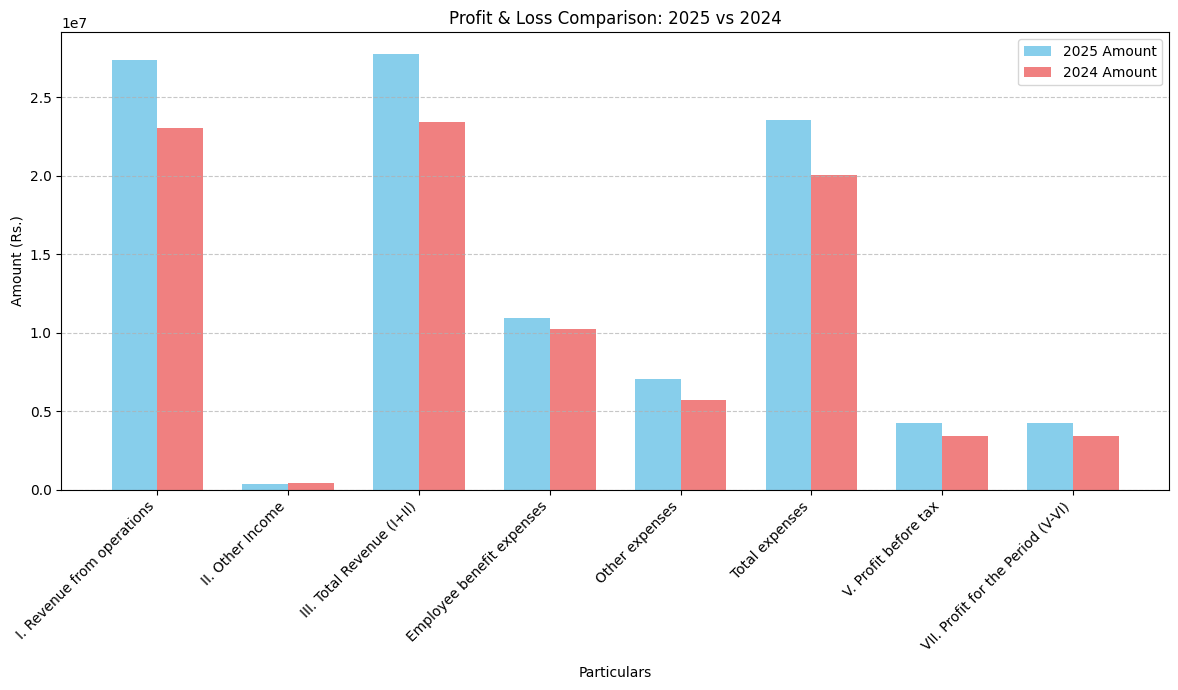

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

comparison_df = profit_loss_section[
    profit_loss_section['Particulars'].str.contains(
        'Revenue from operations|Other Income|Total Revenue|Employee benefit expenses|Other expenses|Total expenses|Profit before tax|Profit for the Period',
        case=False, na=False
    )
].copy()

comparison_df['2025_Amount'] = pd.to_numeric(comparison_df['2025_Amount'], errors='coerce')
comparison_df['2024_Amount'] = pd.to_numeric(comparison_df['2024_Amount'], errors='coerce')


comparison_df = comparison_df.dropna(subset=['2025_Amount', '2024_Amount'], how='all')


fig, ax = plt.subplots(figsize=(12, 7))

bar_width = 0.35
index = np.arange(len(comparison_df))

bar1 = ax.bar(index, comparison_df['2025_Amount'], bar_width, label='2025 Amount', color='skyblue')
bar2 = ax.bar(index + bar_width, comparison_df['2024_Amount'], bar_width, label='2024 Amount', color='lightcoral')

ax.set_xlabel('Particulars')
ax.set_ylabel('Amount (Rs.)')
ax.set_title('Profit & Loss Comparison: 2025 vs 2024')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(comparison_df['Particulars'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
comparison_df['Percentage_Change'] = ((comparison_df['2025_Amount'] - comparison_df['2024_Amount']) / comparison_df['2024_Amount']) * 100
display(comparison_df[['Particulars', '2025_Amount', '2024_Amount', 'Percentage_Change']].round(2))

,Particulars,2025_Amount,2024_Amount,Percentage_Change
2,I. Revenue from operations,27387814.00,23037561.00,18.88
3,II. Other Income,368702.12,408560.76,-9.76
4,III. Total Revenue (I+II),27756516.12,23446121.76,18.38
8,Employee benefit expenses,10925626.20,10231739.03,6.78
11,Other expenses,7082801.07,5738825.50,23.42
12,Total expenses,23527909.37,20032359.69,17.45
14,V. Profit before tax,4228606.75,3413762.07,23.87
20,VII. Profit for the Period (V-VI),4228606.75,3413762.07,23.87


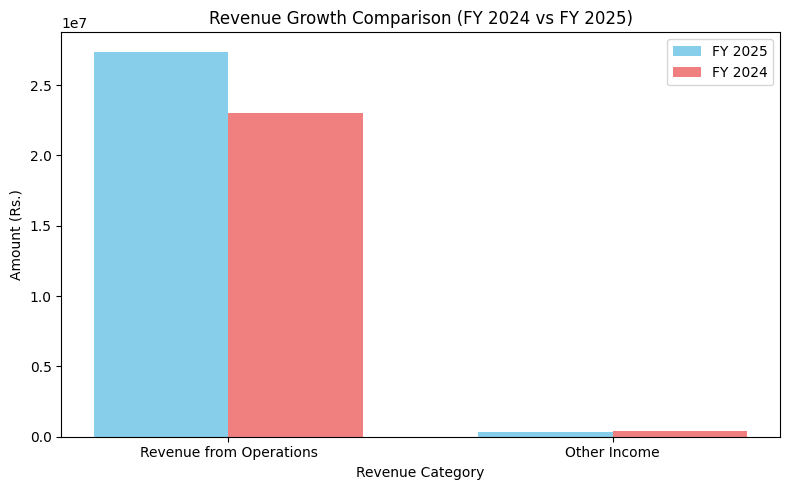

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

revenue_operations_2025 = bs_pl[bs_pl['Particulars'].str.contains('Revenue from operations', case=False, na=False)]['2025_Amount'].iloc[0]
revenue_operations_2024 = bs_pl[bs_pl['Particulars'].str.contains('Revenue from operations', case=False, na=False)]['2024_Amount'].iloc[0]

other_income_2025 = bs_pl[bs_pl['Particulars'].str.contains('Other Income', case=False, na=False)]['2025_Amount'].iloc[0]
other_income_2024 = bs_pl[bs_pl['Particulars'].str.contains('Other Income', case=False, na=False)]['2024_Amount'].iloc[0]


revenue_categories = ['Revenue from Operations', 'Other Income']
fy_2025_values = [revenue_operations_2025, other_income_2025]
fy_2024_values = [revenue_operations_2024, other_income_2024]

bar_width = 0.35
index = np.arange(len(revenue_categories))

plt.figure(figsize=(8, 5))

bar1 = plt.bar(index - bar_width/2, fy_2025_values, bar_width, label='FY 2025', color='skyblue')
bar2 = plt.bar(index + bar_width/2, fy_2024_values, bar_width, label='FY 2024', color='lightcoral')

plt.xlabel('Revenue Category')
plt.ylabel('Amount (Rs.)')
plt.title('Revenue Growth Comparison (FY 2024 vs FY 2025)')
plt.xticks(index, revenue_categories)
plt.legend()
plt.tight_layout()
plt.show()

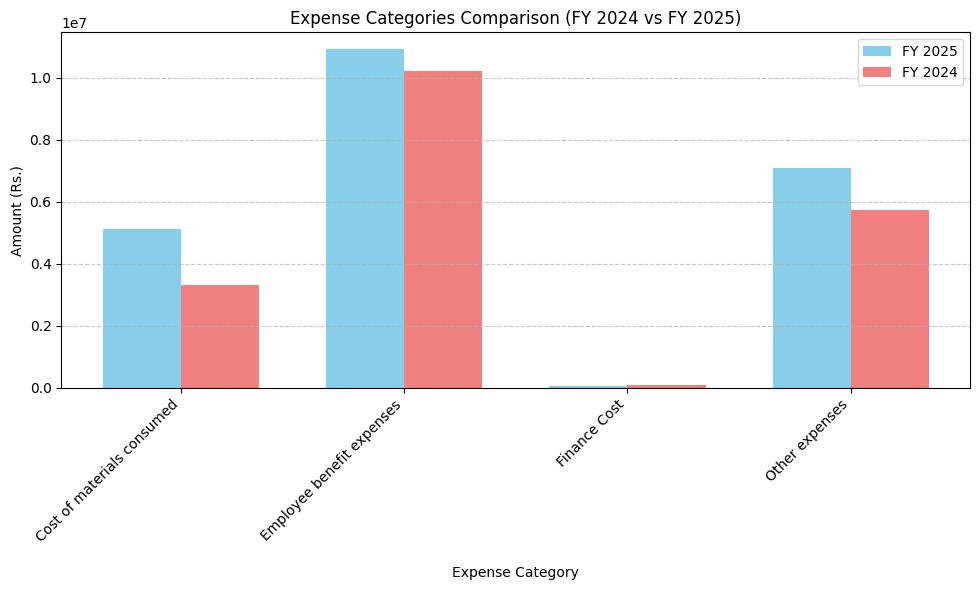

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


expense_categories_to_plot = [
    'Cost of materials consumed',
    'Employee benefit expenses',
    'Finance Cost',
    'Other expenses'
]


filtered_expenses = bs_pl[
    bs_pl['Particulars'].str.contains('|'.join(expense_categories_to_plot), case=False, na=False)
].copy()


plot_categories = filtered_expenses['Particulars'].tolist()
fy_2025_amounts = filtered_expenses['2025_Amount'].tolist()
fy_2024_amounts = filtered_expenses['2024_Amount'].tolist()


bar_width = 0.35
index = np.arange(len(plot_categories))

plt.figure(figsize=(10, 6))

bar1 = plt.bar(index - bar_width/2, fy_2025_amounts, bar_width, label='FY 2025', color='skyblue')
bar2 = plt.bar(index + bar_width/2, fy_2024_amounts, bar_width, label='FY 2024', color='lightcoral')

plt.xlabel('Expense Category')
plt.ylabel('Amount (Rs.)')
plt.title('Expense Categories Comparison (FY 2024 vs FY 2025)')
plt.xticks(index, plot_categories, rotation=45, ha='right') # Rotate for better readability
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

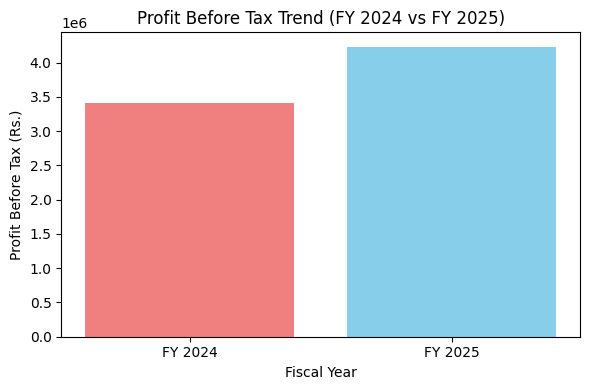

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


profit_before_tax_2025 = bs_pl[bs_pl['Particulars'].str.contains('Profit before tax', case=False, na=False)]['2025_Amount'].iloc[0]
profit_before_tax_2024 = bs_pl[bs_pl['Particulars'].str.contains('Profit before tax', case=False, na=False)]['2024_Amount'].iloc[0]


years = ['FY 2024', 'FY 2025']
profit_values = [profit_before_tax_2024, profit_before_tax_2025]


plt.figure(figsize=(6, 4))
plt.bar(years, profit_values, color=['lightcoral', 'skyblue'])

plt.xlabel('Fiscal Year')
plt.ylabel('Profit Before Tax (Rs.)')
plt.title('Profit Before Tax Trend (FY 2024 vs FY 2025)')
plt.tight_layout()
plt.show()

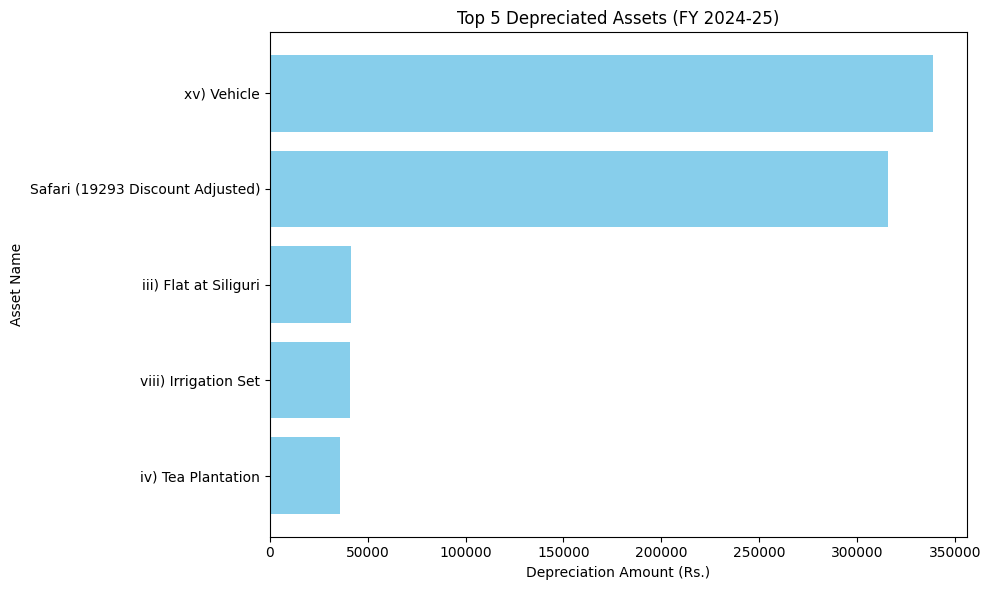

In [ ]:
import matplotlib.pyplot as plt


plot_data_temp = pd.DataFrame({
    'Asset_Name': depreciation_df.iloc[:, 0],
    'Depreciation_Value': depreciation_df.iloc[:, 7]
})

plot_data_temp['Depreciation_Value'] = pd.to_numeric(plot_data_temp['Depreciation_Value'], errors='coerce')

plot_data_temp = plot_data_temp.dropna(subset=['Asset_Name', 'Depreciation_Value'])


top_5_depreciated_assets = plot_data_temp.sort_values(by='Depreciation_Value', ascending=False).head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_5_depreciated_assets['Asset_Name'], top_5_depreciated_assets['Depreciation_Value'], color='skyblue')


plt.gca().invert_yaxis()


plt.title('Top 5 Depreciated Assets (FY 2024-25)')
plt.xlabel('Depreciation Amount (Rs.)')
plt.ylabel('Asset Name')


plt.tight_layout()
plt.show()

In [ ]:
bs_pl.to_excel("Cleaned_BalanceSheet_ProfitLoss.xlsx", index=False)
notes_bs.to_excel("Cleaned_Notes_BalanceSheet.xlsx", index=False)
notes_pl.to_excel("Cleaned_Notes_PL.xlsx", index=False)
depreciation_df.to_excel("Cleaned_Depreciation.xlsx", index=False)
